In [1]:
import jets
import jets.metrics as metrics

In [17]:
config = {
    'exp_name': 'log-test-1',
    'visual': {
        'fields': ['q', 'v'],
        'spectra': ['z', 'e'],
        'means' : ['z_mean', 'e_mean'],
    },
    'atmosphere': {
        'n_grid': 256, 
        'params': {
            'initial': 'zero', 
            'forcing': 'norm',
            'p': 2,
            'nu': 4e-8, 
            'r': 0.01,
            'epsilon': 1.0,
            'kf': 10,
            'dkf': 1.0,
            'forcing_dt': 1/100,
        }
    },
    'integrator': {
        'method': 'rk4',
        'interval': 1,
        'n_points': 100,
    },
}

model = jets.Driver()
model.setup(**config)
model.start()
print(model.descript())

def check_z_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, z_mean = climate['t'][1::], climate['z_mean'][1::]
    z_params, z_found = metrics.find_saturation(t, z_mean)
    if z_found:
        if show:
            metrics.plot_saturation(t, z_mean, z_params, 'z_mean')
        return True, z_params
    else:
        return False, None
    
def check_e_saturation(climate, show=False):
    if len(climate['t'])<=2:
        return False, None
    t, e_mean = climate['t'][1::], climate['e_mean'][1::]
    e_params, e_found = metrics.find_saturation(t, e_mean)
    if e_found:
        if show:
            metrics.plot_saturation(t, e_mean, e_params, 'e_mean')
        return True, e_params
    else:
        return False, None
    
def check_saturation(climate, show=False):
    r = config['atmosphere']['params']['r']
    t_cur = climate['t'].values[-1]
    t_r = 1/r
    if t_cur>3*t_r:
        stop = True
    else:
        stop = False
    return stop, None

[meta]
model = qgc-1
type = quasi-geostrophic
coord = cartesian
approach = spectral-1

[atmosphere]
initial = zero
forcing = norm
initial_seed = 42
forcing_seed = 42
p = 2
beta = 0.0
nu = 4e-08
r = 0.01
kappa = 0.0
epsilon = 1.0
kf = 10
dkf = 1.0
sigma = 1.0
forcing_dt = 0.01

[integrator]
method = rk4
interval = 1
n_points = 100




In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import clear_output
from scipy.optimize import curve_fit

r = config['atmosphere']['params']['r']
nu = config['atmosphere']['params']['nu']
p = config['atmosphere']['params']['p']
k_f = config['atmosphere']['params']['kf']
dk_f = config['atmosphere']['params']['dkf']
A_f = config['atmosphere']['params']['epsilon']

eps = 1/2 * A_f**2 / k_f**2
eta = k_f**2 * eps 
tau_d = (eta)**(-1/3)
k_r = (r**3/eps)**(1/2)
k_d = (1/(nu * tau_d))**(1/(2*p))
Add_oct = 1.5 # (0.5 -//- 1.5)
N_oct = np.log(k_d/k_f)/np.log(2) + Add_oct
N_transmit = (2*p) * N_oct

tau_r = 1/r
tau_nu = tau_d * N_transmit

k_eff = (1/N_transmit * (k_d**(2*p) - k_f**(2*p)))**(1/(2*p))

t_E = 1/2 * tau_r
E_inf = eps * t_E
t_Z = 1/(2/tau_r + 2/tau_nu)
Z_inf = eta * t_Z

def saturation_model(t, A0, t0):
    return A0 * (1 - np.exp(-t/t0))

def fit_saturation(T, A, A0_theory, t0_theory):
    for k in range(7, len(T)):
        clear_output(wait=True)
        a_data, t_data = A[:k:], T[:k:]
        p0 = [A0_theory, t0_theory] 
        
        bounds = ([0, 0], [np.inf, np.inf])

        popt, pcov = curve_fit(saturation_model, t_data, a_data, p0=p0, bounds=bounds)

        A0_est, t0_est = popt
        perr = np.sqrt(np.diag(pcov))
        A_dot_theory = A0_est/t0_theory
        A_dot_est = A0_est/t0_est

        print(f"Optimal parameters:")
        print(f"A0 = {A0_est:.2e} | A0_theory = {A0_theory:.2e}")
        print(f"t0 = {t0_est:.2e} | t0_theory = {t0_theory:.2e}")
        print(f"A_dot = {A_dot_est:.2e} | A_dot_theory = {A_dot_theory:.2e}")
        print(f"Standart deviation: E0 ± {perr[0]:.2e}, t0 ± {perr[1]:.2e}")

        t_fit = np.linspace(t_data[::].min(), t_data.max(), 200)
        A_fit = saturation_model(t_fit, *popt)
        A_theory = saturation_model(t_fit, *p0)

        plt.figure(figsize=(8, 5))
        plt.scatter(t_data, a_data, label='data', color='black', alpha=1.0)
        plt.loglog(t_fit, A_fit, 'g-', label=f'fit: A0={A0_est:.2e}, t0={t0_est:.2e}')
        plt.loglog(t_fit, A_theory, 'b-', label=f'theory: A0={A0_theory:.2e}, t0={t0_theory:.2e}')
        plt.axvline(t0_est, color='r', linestyle='--', label='t_sat')
        plt.xlabel('Time t')
        plt.ylabel('Mean A')
        plt.legend()
        plt.grid(True)
        plt.show()

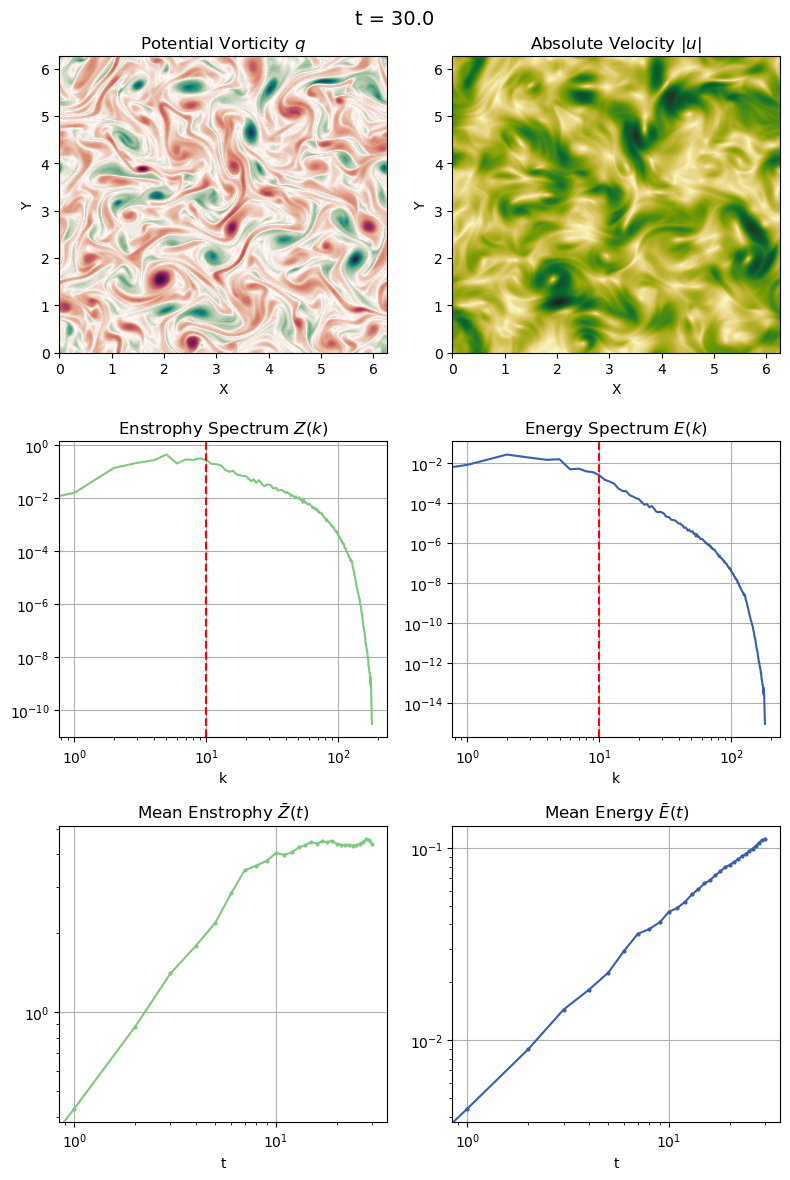

100%|██████████| 31/31 [01:40<00:00,  3.26s/it]


In [19]:
data = model.run(31, show=True, metrics=check_saturation) # logtime=True, tau=2

In [20]:
climate = model.climate

T = climate['t'].values
E_mean = climate['e_mean'].values
Z_mean = climate['z_mean'].values

Optimal parameters:
A0 = 2.24e-01 | A0_theory = 2.50e-01
t0 = 4.41e+01 | t0_theory = 5.00e+01
A_dot = 5.08e-03 | A_dot_theory = 4.48e-03
Standart deviation: E0 ± 7.85e-03, t0 ± 1.98e+00


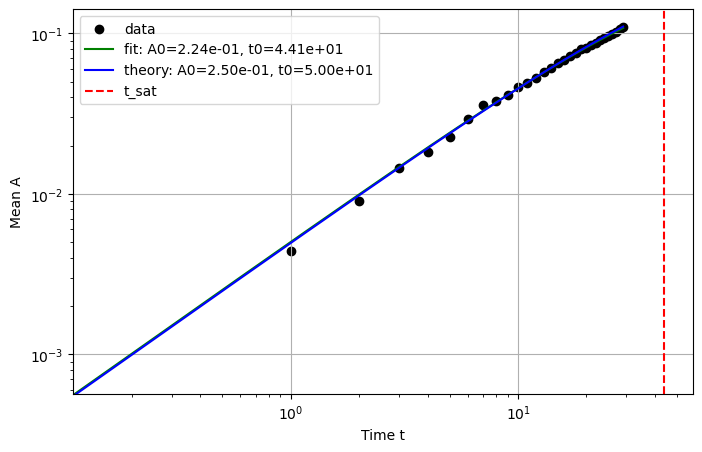

In [21]:
fit_saturation(T, E_mean, E_inf, t_E)

Optimal parameters:
A0 = 4.60e+00 | A0_theory = 4.40e+00
t0 = 6.09e+00 | t0_theory = 8.80e+00
A_dot = 7.56e-01 | A_dot_theory = 5.23e-01
Standart deviation: E0 ± 7.85e-02, t0 ± 3.81e-01


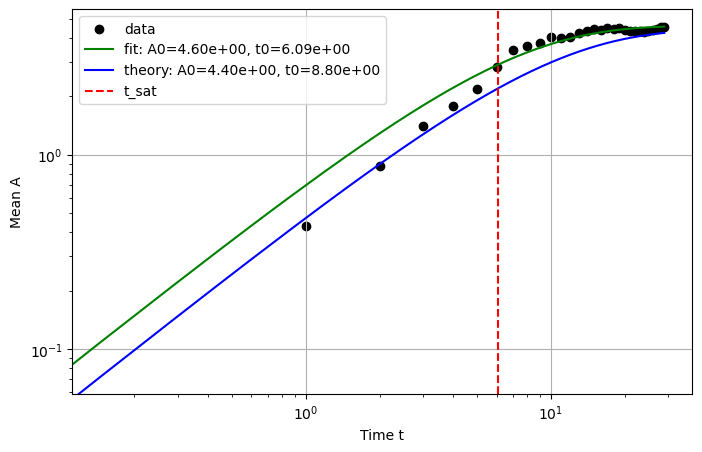

In [26]:
fit_saturation(T, Z_mean, Z_inf, t_Z)

In [29]:
print(k_r, k_f, k_d)

0.014142135623730952 10 66.74199270850171


In [30]:
print(t_Z, tau_nu, t_E)

8.800663942023892 21.36117904822425 50.0


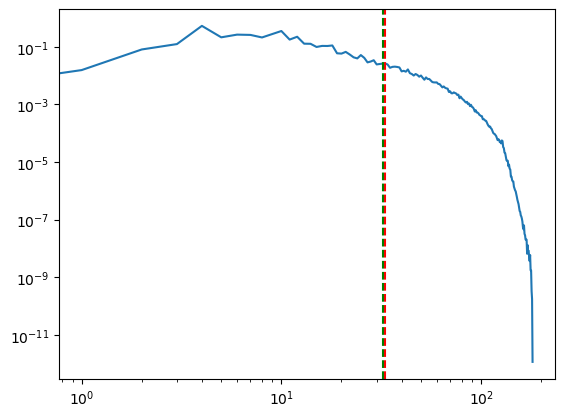

In [28]:
z, k1 = climate['z'].isel(t=-4), climate['k1']
k_eff = (1/N_transmit * (k_d**(2*p)))**(1/(2*p))
k_eff_est = (np.sum(z*k1**(2*p))/(np.sum(z)))**(1/(2*p))

plt.loglog(k1, z)
plt.axvline(k_eff, color='red', linestyle='--')
plt.axvline(k_eff_est, color='green', linestyle='--')